### Importación de datos



In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [13]:
ing_tl = []
import matplotlib.pyplot as plt

In [14]:
def ingresos (Tienda):
  Tienda['Precio'] = pd.to_numeric(Tienda['Precio'], errors='coerce')
  ingreso_total = Tienda['Precio'].sum()
  ing_tl.append(float(ingreso_total))

In [15]:
ingresos(tienda)
ingresos(tienda2)
ingresos(tienda3)
ingresos(tienda4)
ing_tl

[1150880400.0, 1116343500.0, 1098019600.0, 1038375700.0]

In [16]:
print(f'Ingresos tienda 1: ${ing_tl[0]:,.0f} pesos\nIngresos tienda 2: ${ing_tl[1]:,.0f} pesos')
print(f'Ingresos tienda 3: ${ing_tl[2]:,.0f} pesos\nIngresos tienda 4: ${ing_tl[3]:,.0f} pesos')

Ingresos tienda 1: $1,150,880,400 pesos
Ingresos tienda 2: $1,116,343,500 pesos
Ingresos tienda 3: $1,098,019,600 pesos
Ingresos tienda 4: $1,038,375,700 pesos


In [17]:
tiendas_1 = ['Tienda 1','Tienda 2','Tienda 3','Tienda 4']
ing_tl

[1150880400.0, 1116343500.0, 1098019600.0, 1038375700.0]

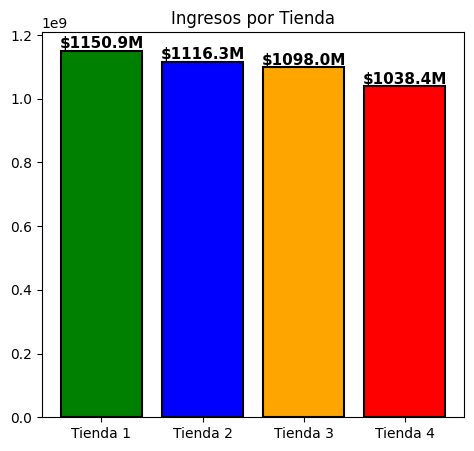

In [48]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
tiendas_1 = ['Tienda 1','Tienda 2','Tienda 3','Tienda 4']
colores= ['green', 'blue', 'orange', 'red']
bars = plt.bar(tiendas_1, ing_tl, color=colores, edgecolor='black', linewidth=1.5)
plt.title('Ingresos por Tienda')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h,
    f'${h/1e6:.1f}M',
    ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

# 2. Ventas por categoría

In [20]:
# tienda['Categoría del Producto'].value_counts().sort_values(ascending=False)

In [72]:
print('Que tipos de producots se venden más en cada tienda:\n')

print('Los tres productos más vendidos en la Tienda 1 son:')
cate = tienda['Categoría del Producto'].value_counts().sort_values(ascending=False).head(3)
for i,(cat, cant) in enumerate(cate.items(), 1):
  print(f'{i}. {cat}: {cant} productos')

print('\nLos tres productos más vendidos en la Tienda 2 son:')
cate = tienda2['Categoría del Producto'].value_counts().sort_values(ascending=False).head(3)
for i,(cat, cant) in enumerate(cate.items(), 1):
  print(f'{i}. {cat}: {cant} productos')

print('\nLos tres productos más vendidos en la Tienda 3 son:')
cate = tienda3['Categoría del Producto'].value_counts().sort_values(ascending=False).head(3)
for i,(cat, cant) in enumerate(cate.items(), 1):
  print(f'{i}. {cat}: {cant} productos')

print('\nLos tres productos más vendidos en la Tienda 4 son:')
cate = tienda4['Categoría del Producto'].value_counts().sort_values(ascending=False).head(3)
for i,(cat, cant) in enumerate(cate.items(), 1):
  print(f'{i}. {cat}: {cant} productos')

Que tipos de producots se venden más en cada tienda:

Los tres productos más vendidos en la Tienda 1 son:
1. Muebles: 465 productos
2. Electrónicos: 448 productos
3. Juguetes: 324 productos

Los tres productos más vendidos en la Tienda 2 son:
1. Muebles: 442 productos
2. Electrónicos: 422 productos
3. Juguetes: 313 productos

Los tres productos más vendidos en la Tienda 3 son:
1. Muebles: 499 productos
2. Electrónicos: 451 productos
3. Juguetes: 315 productos

Los tres productos más vendidos en la Tienda 4 son:
1. Muebles: 480 productos
2. Electrónicos: 451 productos
3. Juguetes: 338 productos


En las cuatro tiendas los tres productos mas vendidos son: **Muebles**: tomando el lugar de mas vendido, **Electrodomesticos**: como el segundo mas vendido y **Juguetes**.

# 3. Calificación promedio de la tienda


In [24]:
calif_tienda = tienda['Calificación'].mean()

In [25]:
calif_tienda2 = tienda2['Calificación'].mean()

In [26]:
calif_tienda3 = tienda3['Calificación'].mean()

In [27]:
calif_tienda4 = tienda4['Calificación'].mean()

In [28]:
print(f'Calificación promedio tienda 1: {calif_tienda:.2f}')
print(f'Calificación promedio tienda 2: {calif_tienda2:.2f}')
print(f'Calificación promedio tienda 3: {calif_tienda3:.2f}')
print(f'Calificación promedio tienda 4: {calif_tienda4:.2f}')

Calificación promedio tienda 1: 3.98
Calificación promedio tienda 2: 4.04
Calificación promedio tienda 3: 4.05
Calificación promedio tienda 4: 4.00


# 4. Productos más y menos vendidos

In [29]:
tienda_max_min = tienda['Producto'].value_counts().sort_values(ascending=False)

In [30]:
tienda2_max_min = tienda2['Producto'].value_counts().sort_values(ascending=False)

In [31]:
tienda3_max_min = tienda3['Producto'].value_counts().sort_values(ascending=False)

In [32]:
tienda4_max_min = tienda4['Producto'].value_counts().sort_values(ascending=False)

In [33]:
tiendas = {
    'Tienda 1': tienda_max_min,
    'Tienda 2': tienda2_max_min,
    'Tienda 3': tienda3_max_min,
    'Tienda 4': tienda4_max_min}

In [89]:
resultados = []

for nombre, serie in tiendas.items():
        resultados.append({
        'Tienda': nombre,
        'Más vendido': serie.idxmax(),
        'Venta maxima': serie.max(),
        'Menos vendido': serie.idxmin(),
        'Venta minima': serie.min()
    })

df_resumen = pd.DataFrame(resultados)

In [90]:
df_resumen

,Tienda,Más vendido,Venta maxima,Menos vendido,Venta minima
0,Tienda 1,Microondas,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


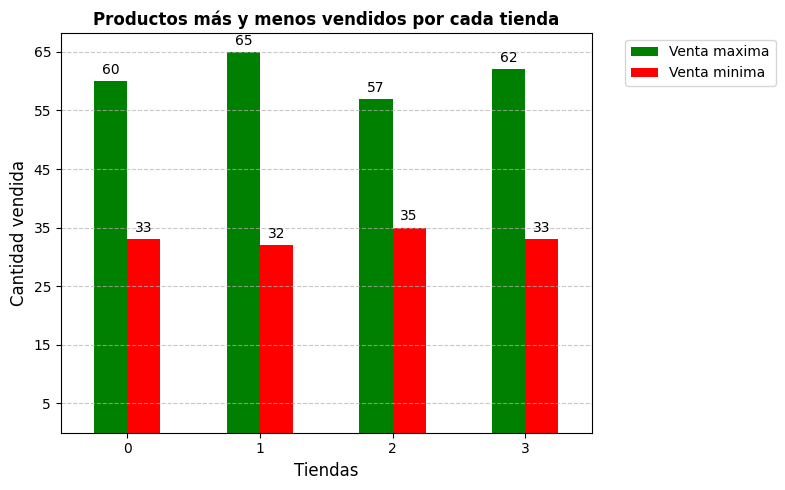

In [91]:
ax = df_resumen.plot(
    kind='bar',
    figsize=(8,5),
    color=['green', 'red'],
)

plt.title('Productos más y menos vendidos por cada tienda', fontsize=12, fontweight='bold')
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Cantidad vendida', fontsize=12)
plt.yticks(range(5, 70, 10))
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')


for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [93]:
cost_envios = {
    'Tienda 1' : tienda['Costo de envío'].mean(),
    'Tienda 2' : tienda2['Costo de envío'].mean(),
    'Tienda 3' : tienda3['Costo de envío'].mean(),
    'Tienda 4' : tienda4['Costo de envío'].mean()
}
print('El costo promedio de envio es de:\n')
for tienda, envio in cost_envios.items():
  print(f'{tienda} : $ {envio:,.2f}')

El costo promedio de envio es de:

Tienda 1 : $ 26,018.61
Tienda 2 : $ 25,216.24
Tienda 3 : $ 24,805.68
Tienda 4 : $ 23,459.46


## 6. Graficos

In [42]:
'''
plt.bar(tiendas_1, ing_tl)
colores =  ['green', 'red', 'blue', 'orange']
plt.bar(tiendas_1, ing_tl, color=colores)
plt.xlabel('TIENDAS')
plt.ylabel('INGRESOS')
plt.title('Ingresos por tienda')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.yticks(range(0,1300000000 ,100000000 ))
plt.show()
'''